# Worksheet 05: Discrete Counts Responses

#### Lecture and Tutorial Learning Goals:
After completing this week's lecture and tutorial work, you will be able to:

1. Describe the Poisson regression estimation procedure (discrete counts as the response variable and explanatory variables).
2. Interpret the coefficients and $p$-values in the Poisson regression settings.
3. Discuss useful Poisson regression diagnostics and explain why they should be performed.
4. Write a computer script to perform Poisson regression and perform model diagnostics. Interpret and communicate the results from that computer script.

In [1]:
# Run this cell before continuing.

library(broom)
library(MASS)
library(glmbb)
library(cowplot)
library(tidyverse)

source("tests_worksheet_05.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()    masks stats::filter()
✖ dplyr::lag()       masks stats::lag()
✖ dplyr::select()    masks MASS::select()
✖ lubridate::stamp() masks cowplot::stamp()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘testthat’


The following object is masked from ‘package:dplyr’:

    matches


The following object is masked from ‘package:purrr’:

    is_null


The following objects are masked from ‘package:readr’:

    edition_get, local_edition


The following object is masked from ‘package:tidyr’:

    matches




## 1. Poisson Regression

Let us proceed with Poisson regression. This class of GLM is intended for cases where the response is a count (i.e., a non-negative integer). Let's start by loading the dataset to be used in this section. The data frame `crabs` ([Brockmann, 1996](https://ubc.summon.serialssolutions.com/2.0.0/link/0/eLvHCXMwrV3JasMwEBUlpZBLl7Sl6YY_oE4sy5sgFEpICKU9NadcjFYSmtghCyRf0t-tJC_EPhRaepMHS8jSSPM0M3oGALkdx67tCYRyKV0GacCp9CBX60RCySMcYiigy2qpOq_F1ZiMLqL0v-mFYrZvvd4JXXcPEnOUZbU1z6W-fxdoh6eO-XQUvDyGCnXrbK_hxCkDDCHKgs9KH20FelDOR_pzWxXbdYhljTEanoF10e8iC6V2SbDK9Pg_H3gOTnPsar1kynYBjkTSAs1yC923wMkkNaVL8NVbkNXn8wcxjJ8b0euaZysTvyuzVJUYH9i6Kpsl1ijVOSbTtPZ2f6V6nYuectnbbLGdb2tNLNP5fjkVi1J-BcbDwbg_svOfQNhMIRdsu4KHEnIsIiQYJoGQvsKQmAuOsE8lojRnrPEIlZQHHIUEEs8PBVHQjaJr0EjSRNwAS8ebmMNk4DHkRYgQSt2ARoxRnzuhJG2AitmNlxnVR3x4REI41sMf6-GP8-GPd20QmVn7RZV4MB7p0u3fq96BZpY-rn1B96CxWW3FgyGOeDR6_g1rIQSN)) is a dataset detailing the **counts** of satellite male crabs residing around a female crab nest: `n_males`. 

> The data frame `crabs` contains 173 observations on horseshoe crabs (*Limulus polyphemus*). The response is the count of male crabs (`n_males`) around a female breeding nest. It is subject to four input variables: a factor for the `color` of the prosoma with four levels, a factor for the condition of the posterior `spine` with three levels, the continuous variables for carapace `width` (cm), and `weight` (g).

Run the cell below before proceeding.

In [2]:
# Load the data
data(crabs)

crabs <- 
    crabs %>%
    as_tibble() %>%
    rename(n_males = satell) %>%
    dplyr::select(-y)

str(crabs)
head(crabs)

tibble [173 × 5] (S3: tbl_df/tbl/data.frame)
 $ color  : Factor w/ 4 levels "dark","darker",..: 4 1 3 1 1 4 3 1 4 1 ...
 $ spine  : Factor w/ 3 levels "bad","good","middle": 1 1 2 1 1 1 2 3 2 1 ...
 $ width  : num [1:173] 28.3 22.5 26 24.8 26 23.8 26.5 24.7 23.7 25.6 ...
 $ n_males: int [1:173] 8 0 9 0 4 0 0 0 0 0 ...
 $ weight : int [1:173] 3050 1550 2300 2100 2600 2100 2350 1900 1950 2150 ...


color,spine,width,n_males,weight
<fct>,<fct>,<dbl>,<int>,<int>
medium,bad,28.3,8,3050
dark,bad,22.5,0,1550
light,good,26.0,9,2300
dark,bad,24.8,0,2100
dark,bad,26.0,4,2600
medium,bad,23.8,0,2100


**Question 1.1**
<br>{points: 1}

Create a scatterplot of `n_males` versus carapace `width` (via `geom_point()`), even though `n_males` is not continuous. The `ggplot()` object's name will be `crabs_vs_width_scatterplot`. Recall that the response must be placed on the $y$-axis, whereas the continuous input must be on the $x$-axis. Include proper axis labels and title.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

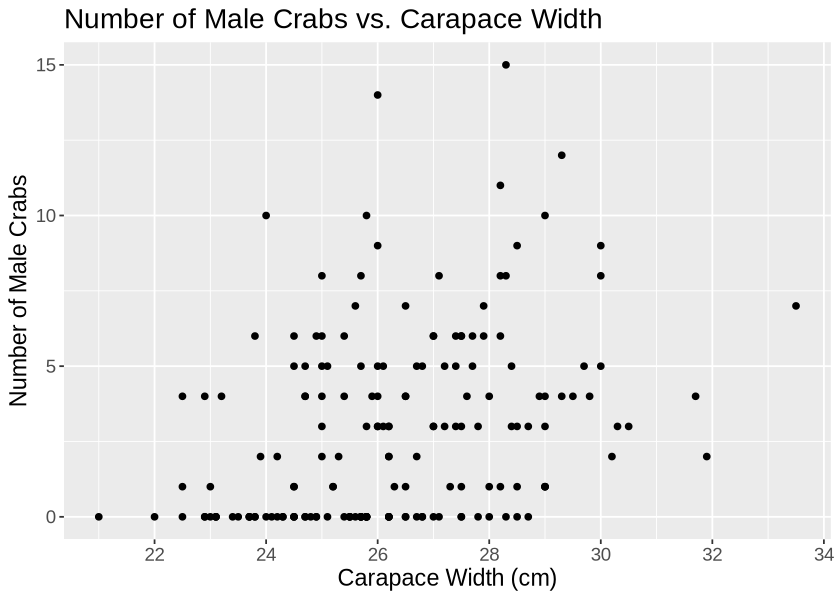

In [5]:
# Adjust these numbers so the plot looks good in your desktop.
options(repr.plot.width = 7, repr.plot.height = 5) 

# crabs_vs_width_scatterplot <- 
#   ... %>%
#   ggplot() +
#   ...(aes(..., ...)) +
#   labs(y = ..., x = ...) +
#   ggtitle(...) +
#   theme(text = element_text(size = 14)) + 
#   scale_x_continuous(breaks = seq(20, 34, 2))

# your code here
crabs_vs_width_scatterplot <- 
  crabs %>%
  ggplot() +
  geom_point(aes(y=n_males, x=width)) +
  labs(y = "Number of Male Crabs", x = "Carapace Width (cm)") +
  ggtitle("Number of Male Crabs vs. Carapace Width") +
  theme(text = element_text(size = 14)) + 
  scale_x_continuous(breaks = seq(20, 34, 2))

crabs_vs_width_scatterplot

In [6]:
test_1.1()

Test passed 🎊
Test passed 🎉
Test passed 😀
Test passed 😀
Test passed 😀
Test passed 🎉
Test passed 🌈
[1] "Success!"


Note the characteristic horizontal pattern in the points of `crabs_vs_width_scatterplot`, since the $y$-axis has repeated counts associated with different `width` values. Graphically speaking, is the carapace `width` variable associated with `n_males`?

From the `crabs_vs_width_scatterplot` above, it is hard to graphically conclude anything about the relationship between `n_males` and caparace `width`. Hence, let us plot the average `n_males` by non-overlapped carapace `width` groups. 

**Question 1.2**
<br>{points: 1}

Create a data frame called `crabs_group_avg_width`, which is created from `crabs` and has two columns:

- `width_intervals`: a column created with column `width` via function `cut()` with `breaks = 10` (i.e., bins).
- `mean_n_males`: the average `n_males` by each bin.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [ ]:
# crabs_group_avg_width <- 
#  ... %>%
#  ...(width_intervals = ...(..., ...)) %>%
#  group_by(...) %>% 
#  summarise(... = ...(...)) 

# your code here
crabs_group_avg_width <- 
 crabs %>%
 ...(width_intervals = cut(width, breaks=10)) %>%
 group_by(width_intervals) %>% 
 summarise(mean_n_males = mean(n_males)) 

crabs_group_avg_width

In [ ]:
test_1.2()

**Question 1.3**
<br>{points: 1}

Create another scatterplot of `mean_n_males` on the $y$-axis versus the carapace `width_intervals` on the $x$-axis using `crabs_group_avg_width` with `geom_point()`. The `ggplot()` object's name will be `crabs_avg_width_scatterplot`. Include proper axis labels and title.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [ ]:
# Adjust these numbers so the plot looks good in your desktop.
options(repr.plot.width = 8, repr.plot.height = 10)

# Crabs_avg_width_scatterplot <- 
#   ... %>%
#   ggplot() +
#   ...(aes(..., ...), colour = "red", size = 4) +
#   labs(y = ..., x = ...) +
#   ggtitle(...) +
#   theme(text = element_text(size = 14), 
#         axis.text.x = element_text(angle = 45, hjust = 1))

# your code here
fail() # No Answer - remove if you provide an answer

plot_grid(crabs_avg_width_scatterplot, crabs_vs_width_scatterplot, ncol = 1)

In [ ]:
test_1.3()

**Question 1.4**
<br>{points: 1}

By looking at `Crabs_avg_width_scatterplot`, graphically speaking, what is the relationship between `n_males` and carapace `width`?

**A.** Positive.

**B.** Negative.

**C.** No relationship.

*Assign your answer to the object `answer1.4` (character type surrounded by quotes).*

In [ ]:
# answer1.4 <- ...

# your code here
fail() # No Answer - remove if you provide an answer

answer1.4

In [ ]:
test_1.4()

Let's compare `crabs_vs_width_scatterplot` and `crabs_avg_width_scatterplot`. We can see that working with the averages of `n_males` by carapace `width` intervals gives us a clearer perspective of the relationship between these two variables. Nonetheless, we need to find a suitable model to confirm this statistically.

Recall that the residual component in an ordinary linear regression model, namely $\varepsilon_i$, is assumed to be Normally distributed, making the response $Y_i$ Normally distributed. In this case, our response variable is the "Number of male crabs" (a count). Count distributions can be asymmetric, and they are non-negative. Thus, the Normal distribution might not be adequate. Nor the logistic regression since we are not estimating proportions. 

A very useful distribution to model counts is the Poisson distribution (it's not the only one). 

**The Poisson Regression**

A Poisson random variable takes discrete non-negative integer values (i.e., 0, 1, 2,...) that count something in a given timeframe or even in a space such as a geographic unit. 

The Poisson regression model is given by:

$$Y_i|\mathbf{X}_i \sim \text{Poisson}(\lambda_i),$$

$$\log(\lambda_i) = \beta_0 + \beta_1X_{1,i} + \ldots + \beta_pX_{1,p}$$

or equivalently,

$$\lambda_i = e^{\beta_0 + \beta_1X_{1,i} + \ldots + \beta_pX_{1,p}}$$

where each variable has its own mean, $\lambda_i$, and variance, also $\lambda_i$. The parameter $\lambda_i$ is interpreted as the risk of an event occurring in a given timeframe or even a space. Note that $\lambda_i$ cannot be negative.

A particularity of the Poisson distribution is that its mean equals its variance. Thus, any factor that affects the mean will also affect the variance. This fact could be a potential drawback for using a Poisson regression model.

**Question 1.5**
<br>{points: 1}

For our `crabs` dataset, the events are the number of male crabs, `n_males,` around a space: the female breeding nest. Suppose we want to make an inference on whether the carapace `width` is related to the response `n_males.` Thus, we could use Poisson regression. Let $\texttt{width}_i$ be the $i$th value for the input `width` in our dataset `crabs`. The model's regression equation will be:

$$\log(\lambda_i) = \beta_0 + \beta_1\texttt{width}_i$$

Let us plot the predictions of this model on top of `crabs_vs_width_scatterplot`. Use `geom_smooth()` with `method = "glm"` and `method.args = list(family = poisson)`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [ ]:
# Adjust these numbers so the plot looks good in your desktop.
options(repr.plot.width = 9, repr.plot.height = 5)

# crabs_vs_width_scatterplot <- 
#   crabs_vs_width_scatterplot +
#   ...(aes(..., ...), 
#       ...,
#       se = FALSE,
#       ...)

# your code here
fail() # No Answer - remove if you provide an answer

crabs_vs_width_scatterplot

In [ ]:
test_1.5()

As seen in other models, the parameters $\beta_0, \beta_1, \dots, \beta_{p}$ are unknown population coefficients that we want to estimate using data. 

In order to fit a Poisson regression model, we can also use the function `glm()` and its argument `family = poisson` (required to specify the Poisson nature of the response), which obtains the estimates $\hat{\beta}_0, \hat{\beta}_1, \dots \hat{\beta}_{p}$. The estimates are obtained through maximum likelihood.

**Question 1.6**
<br>{points: 1}

Using `glm()`, estimate a Poisson regression model with `n_males` as a response and two input variables: `width` and `color` (categorical with 4 levels: `dark`, `darker`, `light` and `medium`) for the $i$th observation:

$$
log(\lambda_i) = \beta_0 + \beta_1 \texttt{width}_i + \beta_2 \texttt{colordarker}_i + \beta_3 \texttt{colorlight}_i + \beta_4 \texttt{colormedium}_i.
$$

> Note that the reference color is `dark`, and we need 3 dummy variables to differenciate it from the other 3 levels

In [ ]:
levels(crabs$color)

Therefore, we have three dummy variables: $\texttt{colordarker}_i$, $\texttt{colorlight}_i$, and $\texttt{colormedium}_i$. Depending on the `color`, these dummy variables take on the following values:

- When `color` is `darker`, then $\texttt{colordarker}_i = 1$ while the other two dummy variables $\texttt{colorlight}_i = \texttt{colormedium}_i = 0$.
- When `color` is `light`, then $\texttt{colorlight}_i = 1$ while the other two dummy variables $\texttt{colordarker}_i = \texttt{colormedium}_i = 0$.
- When `color` is `medium`, then $\texttt{colormedium}_i = 1$ while the other two dummy variables $\texttt{colordarker}_i = \texttt{colorlight}_i = 0$.

Call the model `crabs_poisson_model`.
    
*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*    

In [ ]:
# crabs_poisson_model <- ...(...,
#                            ...,
#                            ...)

# your code here
fail() # No Answer - remove if you provide an answer

summary(crabs_poisson_model)

In [ ]:
test_1.6()

**Question 1.7**
<br>{points: 1}

Report the estimated coefficients, their standard errors, and corresponding $p$-values using `tidy()` with `crabs_poisson_model`. Include the corresponding asymptotic 95% confidence intervals. Store the results in the variable `crabs_poisson_model_results`.

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [ ]:
# crabs_poisson_model_results <- 
#    ...
#    ...(... = TRUE) %>%
#    mutate_if(is.numeric, round, 4)

# your code here
fail() # No Answer - remove if you provide an answer

crabs_poisson_model_results

In [ ]:
test_1.7()

**Question 1.8**
<br>{points: 1}

The table of "raw" estimated coefficients corresponds to a model for log-mean counts. If we want to interpret the estimated coefficients in terms of mean counts, we need to exponentiate the estimated coefficients (recall we are using the logarithmic link function). 

Add to `crabs_poisson_model_results` the exponentiated estimated coefficients and their corresponding 95% confidence interval. 

*Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [ ]:
# crabs_poisson_model_results <- 
#     crabs_poisson_model_results %>%
#     mutate(exp.estimate = ...,
#            exp.conf.low = ...,
#            exp.conf.high = ...) %>%
#     mutate_if(is.numeric, round, 4)

# your code here
fail() # No Answer - remove if you provide an answer

crabs_poisson_model_results


In [ ]:
test_1.8()

As you have done for logistic regression, you can get the exponentiated estimated coefficients using `tidy()`. 

**Recall** that `std.error` and `statistic` are not adjusted when `exponentiate = TRUE`.

In [ ]:
tidy(crabs_poisson_model, exponentiate = FALSE,
     conf.int = TRUE) %>%
     mutate_if(is.numeric, round, 4)

In [ ]:
tidy(crabs_poisson_model, exponentiate = TRUE,
     conf.int = TRUE)%>%
     mutate_if(is.numeric, round, 4)

**Question 1.9**
<br>{points: 1}

Using a significance level $\alpha = 0.05$, and the output in `crabs_Poisson_model_results`, which of the following statements is TRUE?

**A.** There's enough evidence to reject the null hypothesis that the coefficient of `width` is zero (regardless of color).

**B.** There's enough evidence to reject the null hypothesis that, for any width, the mean numbers of male crabs with dark and darker colours of the prosoma are equal.

**C.** There's enough evidence to reject the null hypothesis that, for any width, the mean numbers of male crabs with dark and light colours of the prosoma are equal. 

**D.** There's enough evidence to reject the null hypothesis that, for any width, the mean numbers of male crabs with dark and medium colours of the prosoma are equal.  

*Assign your answers to the object `answer1.9`. Your answers must be included in a single string indicating the correct options in alphabetical order and surrounded by quotes (e.g., `"ABCD"` indicates you are selecting the four options).*

In [ ]:
# answer1.9 <- 

# your code here
fail() # No Answer - remove if you provide an answer

answer1.9

In [ ]:
test_1.9()

**Interpretation of estimated coefficients for continuous covariates** 

Firstly, let us focus on the coefficient interpretation corresponding to `width`, *while keeping `color` constant* (this is an **additive model**).

Consider an observation with a given value ${\texttt{width}} = \texttt{w}$ cm, and another observation with a given ${\texttt{width + 1}} = \texttt{w} + 1$ cm (i.e., an increase of $1$ cm). Then their corresponding regression equations become:

$$
\log \lambda_{\texttt{width}} = \beta_0 + \beta_1 \overbrace{\texttt{w}}^{{\texttt{width}}} + \overbrace{\beta_2 {\texttt{colordarker}} + \beta_3 {\texttt{colorlight}} + \beta_4 {\texttt{colormedium}}}^{\text{Constant}}
$$
$$
\log \lambda_{\texttt{width + 1}} = \beta_0 + \beta_1 \underbrace{(\texttt{w} + 1)}_{{\texttt{width + 1}}} + \underbrace{\beta_2 {\texttt{colordarker}} + \beta_3 {\texttt{colorlight}} + \beta_4 {\texttt{colormedium}}.}_{\text{Constant}}
$$

We take the difference between both equations as:

\begin{align*}
\log \lambda_{\texttt{width + 1}} - \log \lambda_{\texttt{width}} &= \beta_1 (\texttt{w} + 1) - \beta_1 \texttt{w} \\
&= \beta_1
\end{align*}

Then, we apply the logarithm property for a ratio:

\begin{align*}
\log \frac{\lambda_{\texttt{width + 1}} }{\lambda_{\texttt{width}}} &= \log \lambda_{\texttt{width + 1}} - \log \lambda_{\texttt{width}} \\
&= \beta_1
\end{align*}

Finally, we have to exponentiate the previous equation:

$$
\frac{\lambda_{\texttt{width + 1}} }{\lambda_{\texttt{width}}} = e^{\beta_1}
$$

This expression indicates that the mean count varies in a multiplicative way when a continuous covariate increases by 1 unit, i.e., $\lambda_{\texttt{width + 1}}= e^{\beta_1}\lambda_{\texttt{width}}$ 

(This are still the population parameters and the interpretation does not depend on data or estimates)

**Question 1.10**
<br>{points: 1}

**Using the column `exp.estimate` from `crabs_Poisson_model_results`**, what is the correct interpretation of the estimated slope for `width`?

**A.** An increase in the carapace width (`width`) by $1$ cm is associated with a decrease in the estimated counts of male crabs (`n_males`) around a female breeding nest of $161\%$, *for crabs of any color*.

**B.** An increase in the carapace width (`width`) by $1$ cm is associated with an increase in the estimated counts of male crabs (`n_males`) around a female breeding nest of $161\%$, *for crabs of any color*.

**C.** An increase in the carapace width (`width`) by $1$ cm is associated with an increase in the estimated counts of male crabs (`n_males`) around a female breeding nest of $16.1\%$, *for crabs of any color*.

**D.** An increase in the carapace width (`width`) by $1$ cm is associated with a decrease in the estimated counts of male crabs (`n_males`) around a female breeding nest of $16.1\%$, *for crabs of any color*.

**E.** An increase in the carapace width (`width`) by $1$ cm is associated with an increase in the estimated counts of male crabs (`n_males`) around a female breeding nest of $16.1\%$, *for dark crabs*.

**F.** An increase in the carapace width (`width`) by $1$ cm is associated with an increase in counts of male crabs (`n_males`) around a female breeding nest of $161\%$, *for dark crabs*.

*Assign your answer to the object `answer1.10`. Your answer should be one of `"A"`, `"B"`, `"C"`, `"D"`, `"E"`, or `"F"` surrounded by quotes.*

In [ ]:
# answer1.10 <- ...

# your code here
fail() # No Answer - remove if you provide an answer

answer1.10

In [ ]:
test_1.10()

**Interpretation of estimated coefficients of dummy variables** 

*Keeping `width` constant*, at any value (recall assumption of additive models!) consider an observation from the `darker` group: 

Then we have their corresponding regression equations:

$$
\log \lambda_{\texttt{width}} = \beta_0 + \beta_1 \overbrace{\texttt{w}}^{\text{Constant}} + \beta_2 {\texttt{colordarker}} + \beta_3 {\texttt{colorlight}} + \beta_4 {\texttt{colormedium}}
$$

$$
\log \lambda_{\texttt{width,dark}} = \beta_0 + \beta_1 \texttt{w} + \beta_2 \times 0  + \beta_3 \times 0  + \beta_4 \times 0 
$$

$$
\log \lambda_{\texttt{width,darker}} = \beta_0 + \beta_1 \texttt{w} + \beta_2 \times 1 + \beta_3 \times 0 + \beta_4 \times 0.
$$

We take the difference between both equations as:

\begin{align*}
\log \lambda_{\texttt{width,darker}} - \log \lambda_{\texttt{width,dark}} = \beta_2.
\end{align*}

Then, we apply the logarithm property for a ratio:

\begin{align*}
\log \frac{\lambda_{\texttt{width,darker}} }{\lambda_{\texttt{width,dark}}} &= \log \lambda_{\texttt{width,darker}} - \log \lambda_{\texttt{width,dark}} \\
&= \beta_2.
\end{align*}

Finally, we have to exponentiate the previous equation:

$$
\frac{\lambda_{\texttt{width,darker}} }{\lambda_{\texttt{width,dark}}} = e^{\beta_2}.
$$

The expression $\frac{\lambda_{\texttt{width,darker}} }{\lambda_{\texttt{width,dark}}} = e^{\beta_2}$ indicates that the mean count changes in a multiplicative way between the two groups.

**Question 1.11**
<br>{points: 1}

Let us move on to the interpretation of the estimated coefficient of a dummy variable.

Using the `crabs_Poisson_model_results` tibble, what is the correct interpretation of the estimated coefficient for `colorlight`?

**A.** The estimated count of male crabs (`n_males`) around a female breeding nest is $54.7\%$ lower in the  `light` prosoma group compared to the `dark` group, *while keeping the carapace width constant at any value.*

**B.** The estimated count of male crabs (`n_males`) around a female breeding nest is $54.7\%$ higher in the  `light` prosoma group compared to the `dark` group, *while keeping the carapace width constant at any value.*

**C.** The estimated count of male crabs (`n_males`) around a female breeding nest is $154.7\%$ higher in the  `light` prosoma group compared to the `dark` group, *while keeping the carapace width constant at any value.*

**D.** The estimated count of male crabs (`n_males`) around a female breeding nest is $154.7\%$ lower in the  `light` prosoma group compared to the `dark` group, *while keeping the carapace width constant at any value.*

**E.** The estimated count of male crabs (`n_males`) around a female breeding nest is $54.7\%$ lower in the  `dark` prosoma group compared to the `light` group, *while keeping the carapace width constant at any value.*

**F.** The estimated count of male crabs (`n_males`) around a female breeding nest is $54.7\%$ higher in the  `dark` prosoma group compared to the `light` group, *while keeping the carapace width constant at any value.*

*Assign your answer to the object `answer1.11`. Your answer should be one of `"A"`, `"B"`, `"C"`, `"D"`, `"E"`, or `"F"` surrounded by quotes.*

In [ ]:
# answer1.11 <- ...

# your code here
fail() # No Answer - remove if you provide an answer

answer1.11

In [ ]:
test_1.11()

**Question 1.12**
<br>{points: 1}

Suppose we want to predict the mean count of male crabs (`n_males`) around a female breeding nest with a carapace width (`width`) of $27.5$ cm and a light color (`colorlight` = 1) of the prosoma. Then, the corresponding prediction is obtained using the function `predict()` with the object `crabs_poisson_model`.

> **Hint:** Check the argument `type` when coding this prediction.

*Assign your answer to the object `answer1.12`. Fill out those parts indicated with `...`, uncomment the corresponding code in the cell below, and run it.*

In [ ]:
# answer1.12 <- 
#   ...(...,
#     tibble(..., ...),
#     type = ...
#   )

# your code here
fail() # No Answer - remove if you provide an answer

answer1.12

In [ ]:
test_1.12()